# 15 — Iterative Self-Improvement Loop
The model teaches itself ARO in rounds:

```
Round 0  →  base Qwen3-Coder-30B-A3B generates data
            self-repair fixes failures with aro check
            fine-tune on passing samples
            fuse adapter → model_round_1

Round 1  →  model_round_1 generates NEW data (better quality)
            self-repair loop
            fine-tune on round_0 + round_1 data combined
            fuse → model_round_2

Round N  →  ...
```

Each round the model gets better at ARO → generates higher-quality data →
next fine-tune starts from a stronger point.

The initial dataset from notebooks 06–10 (if present) is included in round 0's training set,
so the loop builds directly on top of the warm-start and validated pairs.

**100% local, 100% open-source, runs on Apple Silicon.**

**Prerequisites:** notebooks 01–13 (or at minimum 01–04 + 06–10 + 11)
**Install:** `pip install mlx-lm`

In [1]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'mlx-lm'], check=False)

CompletedProcess(args=['pip', 'install', '-q', 'mlx-lm'], returncode=0)

In [2]:
import json
import os
import re
import random
import subprocess
import sys
import importlib
import tempfile
import time
from collections import Counter
from pathlib import Path
from mlx_lm import load, generate as mlx_generate

try:
    SCRIPT_DIR = Path(__file__).parent.resolve()
except NameError:
    SCRIPT_DIR = Path('.').resolve()

if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))
import config; importlib.reload(config); from config import *

# Route all tempfile operations to the external volume — /var/folders fills up quickly
_TMP_ROOT = DATA_ROOT / 'tmp'
_TMP_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['TMPDIR'] = str(_TMP_ROOT)
tempfile.tempdir = str(_TMP_ROOT)   # also set Python-level override
print(f'Temp dir: {tempfile.gettempdir()}')

MODELS_DIR   = SCRIPT_DIR / '../models'
ROUNDS_DIR   = DATA_ROOT  / 'rounds'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ROUNDS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data root:  {DATA_ROOT}')
print(f'Models dir: {MODELS_DIR}')
print(f'Rounds dir: {ROUNDS_DIR}')

/Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kris/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Temp dir: /Volumes/Models/data/../data/tmp
Data root:  /Volumes/Models/data/../data
Models dir: /Users/kris/Projects/ARO-App/Train/script/../models
Rounds dir: /Volumes/Models/data/../data/rounds


## Loop config

In [ ]:
# Base model for round 0. After each round this is replaced with the fused model.
BASE_MODEL = 'mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit'

NUM_ROUNDS          = 3      # how many improvement rounds to run
SAMPLES_PER_ROUND   = 300    # new samples to generate each round
MAX_REPAIR_ATTEMPTS = 3      # self-repair retries per sample
ITERS_PER_ROUND     = 400    # LoRA training iterations per round
BATCH_SIZE          = 4
LORA_LAYERS         = 8
LEARNING_RATE       = 1e-4   # lowered from 2e-4 — previous value caused loss explosion at ~iter 170

# Training stability guards (applied in run_training)
LOSS_EXPLODE_THRESHOLD = 8.0  # kill training if train_loss spikes above this
EARLY_STOP_PATIENCE    = 3    # stop if val_loss increases this many consecutive checks

# Domains to draw from during generation
DOMAINS = [
    'todo list API', 'user management', 'product catalog', 'order tracking',
    'appointment scheduling', 'inventory alerts', 'support tickets',
    'blog posts with comments', 'event registration', 'notification preferences',
    'subscription billing', 'feature flags', 'team management', 'audit logs',
    'recipe collection', 'book library', 'coupon codes', 'poll system',
    'webhook delivery', 'API key management',
]

print(f'Rounds:           {NUM_ROUNDS}')
print(f'Samples / round:  {SAMPLES_PER_ROUND}')
print(f'Iters / round:    {ITERS_PER_ROUND}')
print(f'Learning rate:    {LEARNING_RATE:.0e}  (reduced from 2e-4)')
print(f'Explosion guard:  >{LOSS_EXPLODE_THRESHOLD}')

## Shared helpers

In [4]:
# Load knowledge base for system prompt
kb_path = DATA_ROOT / '02_knowledge' / 'knowledge.json'
if kb_path.exists():
    with open(kb_path) as f:
        kb = json.load(f)
    action_lines = [
        f'- {"/".join(a["verbs"][:3])}  (role: {a["role"]})'
        for a in kb['actions'] if a['verbs']
    ][:35]
else:
    action_lines = []
    print('WARNING: knowledge.json not found — run notebooks 01+02 first.')

ARO_SYSTEM_PROMPT = f"""You are an expert ARO language programmer.
ARO (Action Result Object) is a DSL for expressing business logic as natural-language statements.

SYNTAX:
  (FeatureSetName: BusinessActivity) {{
      Verb [the] <result[:qualifier]> preposition [the] <object[:qualifier]>.
  }}

KEY RULES:
- String concatenation: ++ (NOT +)
- Variables: hyphenated lowercase e.g. <user-id>
- Forbidden prefixes: is-, with-, empty-
- HTTP path params: Extract the <id> from the <pathParameters: id>.
- Request body: Extract the <data> from the <request: body>.
- Exactly ONE Application-Start per application
- openapi.yaml required for HTTP server
- Return: <OK: status>, <Created: status>, <NotFound: status>

AVAILABLE ACTIONS:
{chr(10).join(action_lines)}

Generate complete, valid ARO that passes `aro check`. Wrap code in ```aro fences."""


def aro_check(code):
    # tempfile.tempdir is set to DATA_ROOT/tmp in the config cell
    try:
        with tempfile.TemporaryDirectory() as tmp:
            (Path(tmp) / 'main.aro').write_text(code)
            r = subprocess.run(['aro', 'check', tmp], capture_output=True, text=True, timeout=10)
            return r.returncode == 0, (r.stderr or r.stdout).strip()[:300]
    except FileNotFoundError:
        return None, 'aro_not_found'
    except subprocess.TimeoutExpired:
        return False, 'timeout'


def extract_aro_blocks(text):
    return [b.strip() for b in re.findall(r'```aro\n(.*?)```', text, re.DOTALL) if b.strip()]


def make_chat_fn(model, tokenizer):
    """Return a chat function bound to the given model."""
    def chat(messages, max_tokens=1200):
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        return mlx_generate(model, tokenizer, prompt=prompt, max_tokens=max_tokens, verbose=False)
    return chat


def generate_with_repair(chat_fn, instruction, max_tokens=1200):
    """Self-repair loop: generate → aro check → fix on failure → repeat."""
    messages = [
        {'role': 'system', 'content': ARO_SYSTEM_PROMPT},
        {'role': 'user',   'content': instruction},
    ]
    for attempt in range(MAX_REPAIR_ATTEMPTS):
        output = chat_fn(messages, max_tokens=max_tokens)
        blocks = extract_aro_blocks(output)

        if not blocks:
            messages += [
                {'role': 'assistant', 'content': output},
                {'role': 'user',      'content': 'Wrap your ARO code in ```aro\\n...\\n```.'},
            ]
            continue

        passed, error = aro_check('\n\n'.join(blocks))
        if passed is True or passed is None:
            return output, attempt

        messages += [
            {'role': 'assistant', 'content': output},
            {'role': 'user',      'content': f'`aro check` error:\n\n```\n{error}\n```\n\nPlease fix the code.'},
        ]
    return None, MAX_REPAIR_ATTEMPTS

## Generation: produce one round of training data

In [5]:
def run_generation_round(round_num, chat_fn, n_samples):
    """Generate n_samples for this round and save to data/rounds/round_{N}.jsonl"""
    output_file = ROUNDS_DIR / f'round_{round_num}.jsonl'
    done = set()
    if output_file.exists():
        with open(output_file) as f:
            for line in f:
                try:
                    s = json.loads(line)
                    done.add(s.get('domain', s.get('source', '')))
                except Exception:
                    pass
        print(f'  Resuming round {round_num}: {len(done)} already saved')

    stats = Counter()
    count = len(done)

    with open(output_file, 'a') as out_f:
        candidates = (DOMAINS * 20)[:n_samples * 3]
        random.shuffle(candidates)

        for domain in candidates:
            if count >= n_samples:
                break
            if domain in done:
                continue

            # 60% code generation, 20% debugging, 20% translation
            roll = random.random()
            if roll < 0.6:
                task = 'code_generation'
                instruction = (
                    f'Write a complete ARO HTTP API for: {domain}.\n'
                    f'Include openapi.yaml and main.aro with Application-Start and all operationId handlers.\n\n'
                    f'## openapi.yaml\n```yaml\n...\n```\n\n## main.aro\n```aro\n...\n```'
                )
            elif roll < 0.8:
                task = 'debugging'
                # Pick a random example to corrupt
                ex_codes = [list(e['aro_files'].values())[0] for e in kb.get('examples', []) if e['aro_files']]
                if not ex_codes:
                    continue
                base_code = random.choice(ex_codes)[:1500]
                bugs = [
                    'Replace one `from` with `with` in a Retrieve statement',
                    'Replace `++` with `+` for string concatenation',
                    'Remove the Application-Start feature set',
                ]
                instruction = (
                    f'Here is valid ARO code:\n\n```aro\n{base_code}\n```\n\n'
                    f'Introduce bug: {random.choice(bugs)}\n\n'
                    f'Then: ## Buggy Code\n```aro\n...\n```\n\n## Fix\n```aro\n...\n```'
                )
            else:
                task = 'translation'
                instruction = (
                    f'Write Python Flask pseudocode for: {domain}. '
                    f'Then translate it to ARO.\n\n'
                    f'## Python\n```python\n...\n```\n\n## ARO\n```aro\n...\n```'
                )

            output, attempts = generate_with_repair(chat_fn, instruction)
            stats[attempts] += 1

            if output:
                sample = {
                    'round': round_num, 'task_type': task,
                    'instruction': instruction[:200], 'output': output,
                    'domain': domain, 'repair_attempts': attempts,
                }
                out_f.write(json.dumps(sample) + '\n')
                out_f.flush()
                done.add(domain)
                count += 1
                if count % 20 == 0:
                    print(f'  [{count}/{n_samples}] last attempts={attempts+1}')

    total = sum(stats.values())
    first_try_rate = 100 * stats.get(0, 0) // max(1, total)
    print(f'  Round {round_num} generation: {count} samples, first-try rate: {first_try_rate}%')
    return count

## Training: fine-tune on all rounds so far

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, clear_output

def prepare_mlx_data(up_to_round, mlx_data_dir):
    """Combine all rounds up to up_to_round into mlx train/valid.jsonl."""
    mlx_data_dir.mkdir(parents=True, exist_ok=True)
    all_samples = []

    # Include initial dataset from notebook 10 if it exists
    initial_train = SCRIPT_DIR / '../data/05_dataset/mlx/train.jsonl'
    if initial_train.exists():
        with open(initial_train) as f:
            for line in f:
                if line.strip():
                    all_samples.append(json.loads(line))

    # Add round data
    for r in range(up_to_round + 1):
        round_file = ROUNDS_DIR / f'round_{r}.jsonl'
        if not round_file.exists():
            continue
        with open(round_file) as f:
            for line in f:
                if not line.strip():
                    continue
                s = json.loads(line)
                output = s.get('output', '')
                instruction = s.get('instruction', '')
                if not output or not instruction:
                    continue
                # Quality guard: skip junk outputs (e.g. all-punctuation, too short)
                if len(output.strip()) < 20:
                    continue
                import re as _re
                if _re.fullmatch(r'[!?.,:;\s]+', output.strip()):
                    continue
                all_samples.append({'messages': [
                    {'role': 'system',    'content': ARO_SYSTEM_PROMPT},
                    {'role': 'user',      'content': instruction},
                    {'role': 'assistant', 'content': output},
                ]})

    random.seed(42)
    random.shuffle(all_samples)
    split = int(len(all_samples) * 0.95)
    train, valid = all_samples[:split], all_samples[split:]

    def write_jsonl(data, path):
        with open(path, 'w') as f:
            for item in data:
                f.write(json.dumps(item) + '\n')

    write_jsonl(train, mlx_data_dir / 'train.jsonl')
    write_jsonl(valid, mlx_data_dir / 'valid.jsonl')
    print(f'  MLX data: {len(train)} train, {len(valid)} valid (rounds 0–{up_to_round})')
    return len(all_samples), len(train), len(valid)


def _draw_loss_plot(ax, fig, train_iters, train_losses, val_iters, val_losses, round_num):
    ax.clear()
    if train_losses:
        ax.plot(train_iters, train_losses, color='steelblue', linewidth=1.5, label='train loss')
    if val_losses:
        ax.plot(val_iters, val_losses, color='tomato', linewidth=2,
                marker='o', markersize=5, label='val loss')
    ax.set_title(f'Round {round_num} — training loss', fontsize=13)
    ax.set_xlabel('iteration')
    ax.set_ylabel('loss')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    clear_output(wait=True)
    display(fig)


def run_training(round_num, data_dir, base_model_path, n_train, n_valid):
    """Run mlx_lm lora for this round, with live loss graph + stability guards."""
    adapter_dir = MODELS_DIR / f'round_{round_num}' / 'adapter'
    adapter_dir.mkdir(parents=True, exist_ok=True)
    log_path = adapter_dir / 'train.log'

    # mlx_lm requires the dataset to have at least batch_size examples.
    effective_batch = max(1, min(BATCH_SIZE, n_train, n_valid))
    val_batches     = max(1, min(10, n_valid // effective_batch))

    cmd = [
        sys.executable, '-m', 'mlx_lm', 'lora',
        '--model',               str(base_model_path),
        '--data',                str(data_dir),
        '--train',
        '--batch-size',          str(effective_batch),
        '--num-layers',          str(LORA_LAYERS),
        '--learning-rate',       str(LEARNING_RATE),
        '--iters',               str(ITERS_PER_ROUND),
        '--save-every',          str(ITERS_PER_ROUND // 2),
        '--val-batches',         str(val_batches),
        '--adapter-path',        str(adapter_dir),
        '--mask-prompt',
    ]

    print(f'  Training round {round_num} '
          f'(batch={effective_batch}, val_batches={val_batches}, lr={LEARNING_RATE:.0e})...')
    print(f'  Log: {log_path}')

    re_train = re.compile(r'Iter\s+(\d+):\s+Train loss\s+([\d.]+)', re.IGNORECASE)
    re_val   = re.compile(r'Iter\s+(\d+):\s+Val loss\s+([\d.]+)',   re.IGNORECASE)

    train_iters, train_losses = [], []
    val_iters,   val_losses   = [], []
    all_lines = []

    # Stability tracking
    _val_loss_streak = 0
    _prev_val_loss   = None
    _stopped_early   = False
    _loss_exploded   = False

    matplotlib.use('module://matplotlib_inline.backend_inline')
    fig, ax = plt.subplots(figsize=(8, 4))

    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    update_every = 5
    last_draw    = 0

    with open(log_path, 'w') as log_f:
        for line in proc.stdout:
            line = line.rstrip()
            all_lines.append(line)
            log_f.write(line + '\n')
            log_f.flush()

            m = re_train.search(line)
            if m:
                it   = int(m.group(1))
                loss = float(m.group(2))
                train_iters.append(it)
                train_losses.append(loss)

                # Loss explosion guard
                if loss > LOSS_EXPLODE_THRESHOLD:
                    _loss_exploded = True
                    print(f'\n🚨  LOSS EXPLOSION at iter {it}: train_loss={loss:.3f} > {LOSS_EXPLODE_THRESHOLD}')
                    print('    Killing training. Reduce LEARNING_RATE and retry.')
                    proc.terminate()
                    break

                if len(train_iters) - last_draw >= update_every:
                    _draw_loss_plot(ax, fig, train_iters, train_losses,
                                    val_iters, val_losses, round_num)
                    last_draw = len(train_iters)
                continue

            m = re_val.search(line)
            if m:
                it   = int(m.group(1))
                loss = float(m.group(2))
                val_iters.append(it)
                val_losses.append(loss)
                _draw_loss_plot(ax, fig, train_iters, train_losses,
                                val_iters, val_losses, round_num)
                last_draw = len(train_iters)

                # Early stopping check
                if _prev_val_loss is not None and loss > _prev_val_loss:
                    _val_loss_streak += 1
                    print(f'  ⚠  val_loss up ({_prev_val_loss:.4f}→{loss:.4f}), '
                          f'streak {_val_loss_streak}/{EARLY_STOP_PATIENCE}')
                    if _val_loss_streak >= EARLY_STOP_PATIENCE:
                        _stopped_early = True
                        print(f'\n⏹  EARLY STOP round {round_num} at iter {it} — val_loss diverging.')
                        proc.terminate()
                        break
                else:
                    _val_loss_streak = 0
                _prev_val_loss = loss

    proc.wait()

    # Final plot
    if train_losses or val_losses:
        _draw_loss_plot(ax, fig, train_iters, train_losses,
                        val_iters, val_losses, round_num)
    plt.close(fig)

    if _loss_exploded:
        raise RuntimeError(
            f'Round {round_num} aborted: loss explosion (>{LOSS_EXPLODE_THRESHOLD}). '
            f'Reduce LEARNING_RATE to {LEARNING_RATE/2:.0e}.'
        )
    if _stopped_early:
        best_it = val_iters[val_losses.index(min(val_losses))] if val_losses else '?'
        print(f'  Early stopped. Best val checkpoint at iter {best_it}.')
    elif proc.returncode not in (0, -15):
        tail = all_lines[-40:] if len(all_lines) >= 40 else all_lines
        print(f'\n--- training failed (last {len(tail)} lines) ---')
        print('\n'.join(tail))
        print(f'--- full log: {log_path} ---')
        raise RuntimeError(f'Training failed at round {round_num} (exit {proc.returncode})')

    # Log summary
    if train_losses:
        print(f'  Train loss: {train_losses[0]:.4f} → {train_losses[-1]:.4f}  '
              f'(best {min(train_losses):.4f})')
    if val_losses:
        print(f'  Val   loss: {val_losses[0]:.4f} → {val_losses[-1]:.4f}  '
              f'(best {min(val_losses):.4f})')

    return adapter_dir


def fuse_model(round_num, base_model_path, adapter_dir):
    """Merge adapter into base weights for the next round's generation."""
    fused_dir = MODELS_DIR / f'round_{round_num}' / 'fused'
    cmd = [
        sys.executable, '-m', 'mlx_lm', 'fuse',
        '--model',        str(base_model_path),
        '--adapter-path', str(adapter_dir),
        '--save-path',    str(fused_dir),
    ]
    print(f'  Fusing round {round_num}...')
    result = subprocess.run(cmd)
    if result.returncode != 0:
        raise RuntimeError(f'Fuse failed at round {round_num}')
    return fused_dir

## Evaluation helper (syntax pass rate)

In [7]:
def quick_eval(model, tokenizer, n=30):
    """Generate n code samples and measure aro check pass rate."""
    chat_fn = make_chat_fn(model, tokenizer)
    passed = 0
    for domain in random.sample(DOMAINS, min(n, len(DOMAINS))):
        instruction = f'Write a short ARO feature set that handles {domain}.'
        messages = [
            {'role': 'system', 'content': ARO_SYSTEM_PROMPT},
            {'role': 'user',   'content': instruction},
        ]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        output = mlx_generate(model, tokenizer, prompt=prompt, max_tokens=600, verbose=False)
        blocks = extract_aro_blocks(output)
        if blocks:
            ok, _ = aro_check('\n\n'.join(blocks))
            if ok is True:
                passed += 1
    rate = passed / n
    print(f'  Syntax pass rate: {passed}/{n} = {rate:.0%}')
    return rate

## Run the loop

In [8]:
round_metrics = []
current_model_path = BASE_MODEL   # starts as HF model id, becomes local path after round 0

# Evaluate base model before any training
print('=== Baseline evaluation ===')
print(f'Loading {current_model_path} ...')
model, tokenizer = load(str(current_model_path))
baseline_rate = quick_eval(model, tokenizer)
round_metrics.append({'round': -1, 'model': str(current_model_path), 'syntax_pass_rate': baseline_rate})
del model   # free VRAM between generation and training

=== Baseline evaluation ===
Loading mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit ...


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 26.77it/s]


  Syntax pass rate: 0/30 = 0%


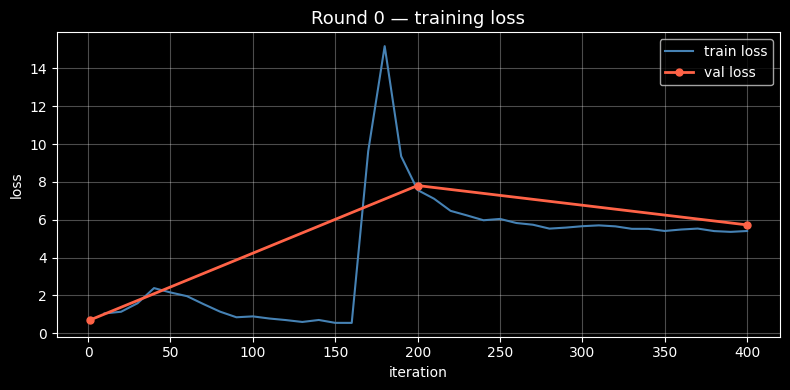

  Fusing round 0...


/Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loading pretrained model


Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 172368.66it/s]


Evaluating round 0 model...


In [ ]:
for round_num in range(NUM_ROUNDS):
    t_start = time.time()
    print(f'\n{"="*60}')
    print(f'ROUND {round_num}')
    print(f'{"="*60}')

    # --- 1. Load current model for generation ---
    print(f'Loading model: {current_model_path}')
    model, tokenizer = load(str(current_model_path))
    chat_fn = make_chat_fn(model, tokenizer)

    # --- 2. Generate ---
    print(f'Generating {SAMPLES_PER_ROUND} samples...')
    n_generated = run_generation_round(round_num, chat_fn, SAMPLES_PER_ROUND)

    # Free model memory before training
    del model, tokenizer, chat_fn

    # --- 3. Prepare combined MLX dataset ---
    mlx_data_dir = ROUNDS_DIR / f'mlx_round_{round_num}'
    total_samples, n_train, n_valid = prepare_mlx_data(round_num, mlx_data_dir)

    # --- 4. Fine-tune ---
    adapter_dir = run_training(round_num, mlx_data_dir, current_model_path, n_train, n_valid)

    # --- 5. Fuse adapter → new model ---
    fused_dir = fuse_model(round_num, current_model_path, adapter_dir)
    current_model_path = fused_dir   # use fused model for next round

    # --- 6. Evaluate new model ---
    print(f'Evaluating round {round_num} model...')
    model, tokenizer = load(str(fused_dir))
    pass_rate = quick_eval(model, tokenizer)
    del model

    elapsed = (time.time() - t_start) / 60
    round_metrics.append({
        'round':            round_num,
        'model':            str(fused_dir),
        'n_generated':      n_generated,
        'total_dataset':    total_samples,
        'syntax_pass_rate': pass_rate,
        'minutes':          round(elapsed, 1),
    })

    print(f'Round {round_num} done in {elapsed:.0f} min. Syntax pass rate: {pass_rate:.0%}')

    # Save progress
    with open(MODELS_DIR / 'loop_metrics.json', 'w') as f:
        json.dump(round_metrics, f, indent=2)

## Results

In [ ]:
print('\n=== Self-Improvement Summary ===\n')
print(f'{"Round":<8} {"Pass Rate":<12} {"Dataset":<12} {"Minutes":<10} {"Model"}')
print('─' * 70)
for m in round_metrics:
    r     = m['round']
    label = 'baseline' if r == -1 else str(r)
    rate  = f'{m["syntax_pass_rate"]:.0%}'
    ds    = str(m.get('total_dataset', '—'))
    mins  = str(m.get('minutes', '—'))
    mod   = Path(m['model']).name if Path(m['model']).exists() else m['model'].split('/')[-1]
    print(f'{label:<8} {rate:<12} {ds:<12} {mins:<10} {mod}')

print(f'\nFinal model: {current_model_path}')
print(f'Metrics:     {MODELS_DIR / "loop_metrics.json"}')

## Summary

In [ ]:
print('=' * 65)
print('NOTEBOOK 17 — ITERATIVE SELF-IMPROVEMENT SUMMARY')
print('=' * 65)

print(f'\nConfiguration:')
print(f'  Rounds:          {NUM_ROUNDS}')
print(f'  Samples/round:   {SAMPLES_PER_ROUND}')
print(f'  Iters/round:     {ITERS_PER_ROUND}')
print(f'  Learning rate:   {LEARNING_RATE:.0e}')
print(f'  Batch size:      {BATCH_SIZE}')
print(f'  LoRA layers:     {LORA_LAYERS}')

if round_metrics:
    baseline = next((m for m in round_metrics if m['round'] == -1), None)
    final    = round_metrics[-1]

    print(f'\nProgress:')
    for m in round_metrics:
        r     = m['round']
        label = 'baseline' if r == -1 else f'round {r}'
        rate  = f'{m["syntax_pass_rate"]:.0%}'
        ds    = f'{m.get("total_dataset","?"):,}' if isinstance(m.get("total_dataset"), int) else '—'
        mins  = f'{m.get("minutes","?"):.0f}m' if isinstance(m.get("minutes"), (int, float)) else '—'
        print(f'  {label:<12}  pass_rate={rate:<6}  dataset={ds:<8}  time={mins}')

    if baseline and len(round_metrics) > 1:
        start_rate = baseline['syntax_pass_rate']
        end_rate   = final['syntax_pass_rate']
        delta      = end_rate - start_rate
        print(f'\nImprovement: {start_rate:.0%} → {end_rate:.0%}  (Δ {delta:+.0%})')
        if end_rate < 0.10:
            print('  ⚠  Syntax pass rate still very low (<10%). Model is not learning ARO.')
            print('     Check data quality in NB14 and ensure aro check works on generated samples.')
        elif end_rate < 0.30:
            print('  ⚠  Modest improvement but still low. Run more rounds or increase SAMPLES_PER_ROUND.')
        else:
            print('  ✓  Meaningful syntax pass rate improvement.')
else:
    print('\n  (no round metrics recorded)')

print(f'\nFinal model: {current_model_path}')
print(f'Metrics log: {MODELS_DIR / "loop_metrics.json"}')

print(f'\nNext steps:')
print(f'  1. Run NB16 (evaluation) on final model to get full metric breakdown.')
print(f'  2. If pass_rate < 20%, re-run NB14 to rebuild dataset with better balance.')
print(f'  3. If loss exploded in any round, LEARNING_RATE is still too high — try {LEARNING_RATE/2:.0e}.')
print('=' * 65)